# HEC-RAS Simulation Output Folder Assessment

This interactive diagnostic notebook assesses the content and hydraulic validity of a single simulation output folder from `Data Collections/automated_runs/`.

### Key Assessment Capabilities:
1. **Directory Inventory & File Integrity**: Confirms all essential files (`.u01`, `.p05.hdf`, `.b05`, `.r05`) exist, are non-empty, and valid.
2. **Unsteady Flow Setup (`.u01`)**: Parses boundary inflow hydrographs (Ai Nghia, Tuy Loan, Vu Gia) and verifies all 7 initial reach flow conditions against `workflow.txt`.
3. **Plan Metadata & Simulation Execution (`.p05.hdf`)**: Extracts simulation start/end timestamps, computation steps, output frequency, and runtime metrics.
4. **1D Hydraulic Analysis (River Cross-Sections)**: Evaluates Water Surface Elevation (WSE), discharge ($Q$), and flow velocity across all 545 cross sections and all 7 river reaches.
5. **1D Profile & Hydrograph Visualizations**: Plots hydrographs at boundary/confluence stations and longitudinal WSE profiles along river reaches.
6. **2D Flow Areas Assessment (`Perimeter 1` & `Perimeter 2`)**: Calculates cell-by-cell inundation depth, peak flooded area ($km^2$), and generates 2D flood depth maps and distributions.
7. **Consolidated Assessment Summary & Export**: Compiles key metrics into an exportable summary report.


In [1]:
# Cell 1: Environment Setup, Imports, and Target Run Selection
import os
import sys
from pathlib import Path
import datetime
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Styling configuration
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Locate the automated_runs directory (supports running from repo root or Scripts/)
SCRIPT_DIR = Path.cwd()
POSSIBLE_RUNS_DIRS = [
    SCRIPT_DIR / 'Data Collections' / 'automated_runs',
    SCRIPT_DIR.parent / 'Data Collections' / 'automated_runs',
    Path(r'D:\flood prediction\Data Collections\automated_runs'),
]

RUNS_DIR = None
for p in POSSIBLE_RUNS_DIRS:
    if p.exists() and p.is_dir():
        RUNS_DIR = p.resolve()
        break

if RUNS_DIR is None:
    raise FileNotFoundError('Could not locate Data Collections/automated_runs directory.')

print(f'[INFO] Runs Base Directory: {RUNS_DIR}')

# Discover available run folders
available_runs = sorted([d.name for d in RUNS_DIR.iterdir() if d.is_dir()])
print(f'[INFO] Found {len(available_runs)} simulation run folder(s).')

# =========================================================================
# CONFIGURATION: Select the specific run folder to assess
# You can change TARGET_RUN_ID to any folder name from available_runs
# =========================================================================
TARGET_RUN_ID = available_runs[0] if available_runs else '2022-10-09_to_2022-10-10'

TARGET_DIR = RUNS_DIR / TARGET_RUN_ID
print(f'\n[TARGET] Selected Target Run: {TARGET_RUN_ID}')
print(f'[PATH]   Directory: {TARGET_DIR}')

if not TARGET_DIR.exists():
    raise FileNotFoundError(f'Selected target directory does not exist: {TARGET_DIR}')


[INFO] Runs Base Directory: D:\flood prediction\Data Collections\automated_runs
[INFO] Found 28 simulation run folder(s).

[TARGET] Selected Target Run: 2022-10-09_to_2022-10-10
[PATH]   Directory: D:\flood prediction\Data Collections\automated_runs\2022-10-09_to_2022-10-10


In [2]:
# Cell 2: Folder Inventory & File Integrity Check
EXPECTED_FILES = {
    'danangfloodmodel.u01': 'Unsteady Flow Boundary & Initial Conditions',
    'danangfloodmodel.p05.hdf': 'HEC-RAS Hydraulic Results (HDF5)',
    'danangfloodmodel.b05': 'Plan Computational Settings / Summary',
    'danangfloodmodel.r05': 'Plan Unsteady Results File',
}

file_records = []
for file_name, file_desc in EXPECTED_FILES.items():
    fpath = TARGET_DIR / file_name
    present = fpath.exists()
    size_bytes = fpath.stat().st_size if present else 0
    size_str = (
        f'{size_bytes / (1024 * 1024):.2f} MB'
        if size_bytes >= 1024 * 1024
        else f'{size_bytes / 1024:.1f} KB'
        if size_bytes > 0
        else '0 B'
    )
    mtime = (
        datetime.datetime.fromtimestamp(fpath.stat().st_mtime).strftime('%Y-%m-%d %H:%M:%S')
        if present
        else '-'
    )
    status = 'OK' if present and size_bytes > 0 else 'MISSING'

    file_records.append({
        'File Name': file_name,
        'Description': file_desc,
        'Status': status,
        'Size': size_str,
        'Last Modified': mtime,
    })

inventory_df = pd.DataFrame(file_records)
print('=== FILE INVENTORY & INTEGRITY REPORT ===')
display(inventory_df)

missing_critical = [
    r['File Name'] for r in file_records
    if r['Status'] == 'MISSING' and ('u01' in r['File Name'] or 'hdf' in r['File Name'])
]
if missing_critical:
    print(f'\n[WARNING] Missing critical simulation file(s): {", ".join(missing_critical)}')
else:
    print('\n[OK] All essential simulation input and output files are present and non-empty.')


=== FILE INVENTORY & INTEGRITY REPORT ===


,File Name,Description,Status,Size,Last Modified
0,danangfloodmodel.u01,Unsteady Flow Boundary & Initial Conditions,OK,886.6 KB,2026-09-23 23:09:12
1,danangfloodmodel.p05.hdf,HEC-RAS Hydraulic Results (HDF5),OK,133.09 MB,2026-09-23 08:48:02
2,danangfloodmodel.b05,Plan Computational Settings / Summary,OK,7.3 KB,2026-09-23 08:36:33
3,danangfloodmodel.r05,Plan Unsteady Results File,OK,1.36 MB,2026-09-23 08:47:48



[OK] All essential simulation input and output files are present and non-empty.


=== INITIAL FLOW CONDITIONS (.u01) ===


,River,Reach,River Station,Initial Flow (m3/s)
0,Ai Nghia,Main Reach,6399,165.421880
1,Cam Le,Main Reach,9000,164.318800
2,Han,Main Reach,7602,312.561887
3,Lac Thanh,Main Reach,23600,148.243087
4,Tuy Loan,Main Reach,9800,18.437500
5,Vu Gia,Main Reach,39160,101.928124
6,Yen,Main Reach,14400,17.178793



=== BOUNDARY CONDITIONS (.u01) ===


,River,Reach,River Station,BC Type,Interval,Data Points,Peak Inflow (m3/s),Min Inflow (m3/s)
0,Ai Nghia,Main Reach,6399,Flow Hydrograph,1HOUR,33,968.44,165.42
1,Han,Main Reach,200,Normal Depth / Stage,-,-,-,-
2,Han,Main Reach,200,Normal Depth / Stage,-,-,-,-
3,Tuy Loan,Main Reach,9800,Flow Hydrograph,1HOUR,48,53.13,18.44
4,Vu Gia,Main Reach,39160,Flow Hydrograph,1HOUR,48,821.63,101.93
5,Vu Gia,Main Reach,199,Normal Depth / Stage,-,-,-,-
6,Vu Gia,Main Reach,199,Normal Depth / Stage,-,-,-,-


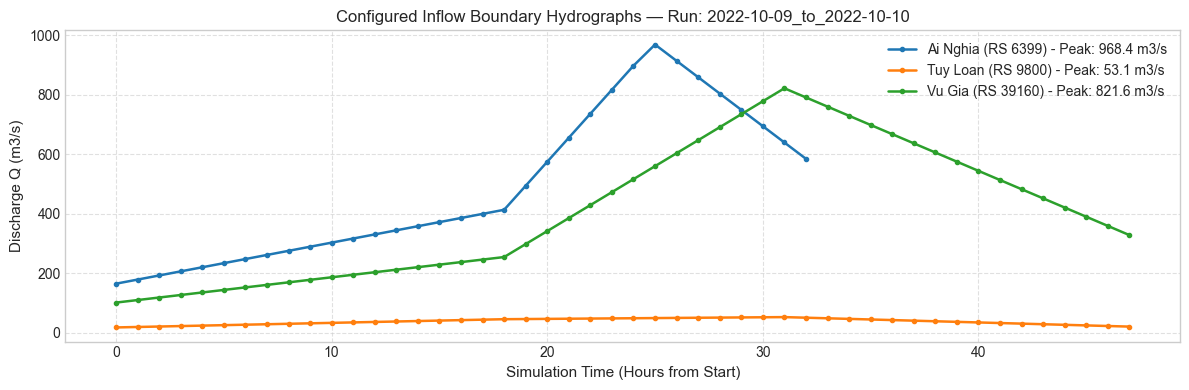

In [3]:
# Cell 3: Unsteady Flow Setup Assessment (.u01)
u01_file = TARGET_DIR / 'danangfloodmodel.u01'

if not u01_file.exists():
    print(f'[WARN] {u01_file.name} not found in {TARGET_DIR.name}')
else:
    u01_text = u01_file.read_text(encoding='utf-8', errors='ignore')
    lines = u01_text.splitlines()

    # 1. Parse Initial Flow Conditions
    initial_flows = []
    for line in lines:
        if line.startswith('Initial Flow Loc='):
            payload = line.split('=', 1)[1]
            parts = [p.strip() for p in payload.split(',')]
            if len(parts) >= 4:
                initial_flows.append({
                    'River': parts[0],
                    'Reach': parts[1],
                    'River Station': parts[2],
                    'Initial Flow (m3/s)': float(parts[3]),
                })
    init_df = pd.DataFrame(initial_flows)

    # 2. Parse Boundary Conditions & Hydrographs
    bcs = []
    i = 0
    while i < len(lines):
        line = lines[i]
        if line.startswith('Boundary Location='):
            payload = line.split('=', 1)[1]
            parts = [p.strip() for p in payload.split(',')]
            river = parts[0] if len(parts) > 0 else ''
            reach = parts[1] if len(parts) > 1 else ''
            rs = parts[2] if len(parts) > 2 else ''
            
            bc_type = 'Normal Depth / Stage'
            interval = '-'
            values = []
            j = i + 1
            while j < len(lines) and not lines[j].startswith('Boundary Location='):
                sub = lines[j]
                if sub.startswith('Flow Hydrograph='):
                    bc_type = 'Flow Hydrograph'
                elif sub.startswith('Interval='):
                    interval = sub.split('=', 1)[1].strip()
                elif bc_type == 'Flow Hydrograph' and not sub.startswith('Flow Hydrograph Slope=') and not sub.startswith('Critical Boundary Flow='):
                    tokens = sub.split()
                    for tok in tokens:
                        try:
                            values.append(float(tok))
                        except ValueError:
                            pass
                j += 1
            
            bcs.append({
                'River': river,
                'Reach': reach,
                'River Station': rs,
                'BC Type': bc_type,
                'Interval': interval,
                'Data Points': len(values) if bc_type == 'Flow Hydrograph' else '-',
                'Peak Inflow (m3/s)': f'{max(values):.2f}' if values else '-',
                'Min Inflow (m3/s)': f'{min(values):.2f}' if values else '-',
                'Values': values,
            })
            i = j - 1
        i += 1

    bc_df = pd.DataFrame([{k: v for k, v in b.items() if k != 'Values'} for b in bcs])

    print('=== INITIAL FLOW CONDITIONS (.u01) ===')
    display(init_df)

    print('\n=== BOUNDARY CONDITIONS (.u01) ===')
    display(bc_df)

    # Plot Boundary Flow Hydrographs
    hydro_bcs = [b for b in bcs if b['BC Type'] == 'Flow Hydrograph' and b['Values']]
    if hydro_bcs:
        plt.figure(figsize=(12, 4))
        for b in hydro_bcs:
            vals = b['Values']
            hours = np.arange(len(vals))
            label = f"{b['River']} (RS {b['River Station']}) - Peak: {float(b['Peak Inflow (m3/s)']):.1f} m3/s"
            plt.plot(hours, vals, marker='.', label=label, linewidth=1.8)
        plt.title(f'Configured Inflow Boundary Hydrographs — Run: {TARGET_RUN_ID}')
        plt.xlabel('Simulation Time (Hours from Start)')
        plt.ylabel('Discharge Q (m3/s)')
        plt.legend()
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()


In [4]:
# Cell 4: Simulation Execution Metadata & Time Window (.p05.hdf)
hdf_file = TARGET_DIR / 'danangfloodmodel.p05.hdf'

if not hdf_file.exists():
    print(f'[WARN] {hdf_file.name} does not exist.')
else:
    with h5py.File(hdf_file, 'r') as hdf:
        # 1. Plan metadata
        plan_data = hdf.get('Plan Data', {})
        plan_info = plan_data.get('Plan Information', None)
        plan_attrs = {}
        if plan_info is not None:
            for k in plan_info.attrs:
                val = plan_info.attrs[k]
                plan_attrs[k] = val.decode('utf-8') if isinstance(val, bytes) else str(val)

        # 2. Time series output timestamps
        ts_group = hdf['Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series']
        raw_stamps = ts_group['Time Date Stamp'][:]
        time_stamps = [t.decode('utf-8').strip() if isinstance(t, bytes) else str(t).strip() for t in raw_stamps]

        start_time_str = time_stamps[0] if time_stamps else 'N/A'
        end_time_str = time_stamps[-1] if time_stamps else 'N/A'
        total_steps = len(time_stamps)

        print('=== SIMULATION EXECUTION METADATA ===')
        print(f'Plan Title:       {plan_attrs.get("Plan Title", "N/A")}')
        print(f'Plan ShortID:     {plan_attrs.get("Plan ShortID", "N/A")}')
        print(f'Simulation Start: {start_time_str}')
        print(f'Simulation End:   {end_time_str}')
        print(f'Total Timesteps:  {total_steps}')


=== SIMULATION EXECUTION METADATA ===
Plan Title:       Plan 05
Plan ShortID:     Plan 05
Simulation Start: 14OCT2022 00:00:00
Simulation End:   15OCT2022 12:00:00
Total Timesteps:  37


In [5]:
# Cell 5: 1D River Cross-Sections Hydraulic Assessment
with h5py.File(hdf_file, 'r') as hdf:
    xs_group = hdf['Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/Cross Sections']
    raw_attrs = xs_group['Cross Section Attributes'][:]
    
    # Cross-section attributes: River, Reach, RS
    xs_df = pd.DataFrame({
        'River': [a[0].decode('utf-8').strip() for a in raw_attrs],
        'Reach': [a[1].decode('utf-8').strip() for a in raw_attrs],
        'RS_str': [a[2].decode('utf-8').strip() for a in raw_attrs],
        'RS': [float(a[2].decode('utf-8').strip().replace('*', '')) for a in raw_attrs],
        'xs_index': np.arange(len(raw_attrs))
    })

    # Extract flow, water surface elevation, and velocity matrices
    wse_matrix = xs_group['Water Surface'][:]      # shape: (timesteps, n_cross_sections)
    flow_matrix = xs_group['Flow'][:]              # shape: (timesteps, n_cross_sections)
    vel_matrix = xs_group['Velocity Total'][:] if 'Velocity Total' in xs_group else xs_group.get('Velocity Channel', None)[:]

    # Hydraulic statistics per cross-section
    xs_df['Peak_Flow_m3s'] = np.nanmax(flow_matrix, axis=0)
    xs_df['Min_Flow_m3s'] = np.nanmin(flow_matrix, axis=0)
    xs_df['Peak_WSE_m'] = np.nanmax(wse_matrix, axis=0)
    xs_df['Min_WSE_m'] = np.nanmin(wse_matrix, axis=0)
    xs_df['Max_Vel_ms'] = np.nanmax(vel_matrix, axis=0) if vel_matrix is not None else np.nan

    # Reach summary aggregated across all 7 reaches
    reach_summary = xs_df.groupby('River').agg(
        Cross_Sections=('xs_index', 'count'),
        Max_Peak_Flow_m3s=('Peak_Flow_m3s', 'max'),
        Max_Peak_WSE_m=('Peak_WSE_m', 'max'),
        Max_Velocity_ms=('Max_Vel_ms', 'max')
    ).reset_index()

print('=== 1D RIVER NETWORK HYDRAULIC SUMMARY ===')
display(reach_summary.style.format({
    'Max_Peak_Flow_m3s': '{:.2f}',
    'Max_Peak_WSE_m': '{:.2f}',
    'Max_Velocity_ms': '{:.2f}',
}))

print('\n=== TOP 5 HIGHEST FLOW CROSS SECTIONS ===')
display(xs_df.sort_values(by='Peak_Flow_m3s', ascending=False)[
    ['River', 'Reach', 'RS_str', 'Peak_Flow_m3s', 'Peak_WSE_m', 'Max_Vel_ms']
].head(5))

print('\n=== TOP 5 HIGHEST WATER LEVEL CROSS SECTIONS ===')
display(xs_df.sort_values(by='Peak_WSE_m', ascending=False)[
    ['River', 'Reach', 'RS_str', 'Peak_WSE_m', 'Peak_Flow_m3s', 'Max_Vel_ms']
].head(5))


=== 1D RIVER NETWORK HYDRAULIC SUMMARY ===


,River,Cross_Sections,Max_Peak_Flow_m3s,Max_Peak_WSE_m,Max_Velocity_ms
0,Ai Nghia,32,12016.39,22.27,2.64
1,Cam Le,45,1129.76,6.83,0.53
2,Han,37,2094.96,6.29,0.98
3,Lac Thanh,115,23353.32,21.45,29263.70
4,Tuy Loan,48,420.35,7.11,0.79
5,Vu Gia,196,6242.29,28.79,5.34
6,Yen,72,15846.47,27.62,2021175.12



=== TOP 5 HIGHEST FLOW CROSS SECTIONS ===


,River,Reach,RS_str,Peak_Flow_m3s,Peak_WSE_m,Max_Vel_ms
221,Lac Thanh,Main Reach,18599.99,23353.320312,19.966280,4.544521
220,Lac Thanh,Main Reach,18800.00,21069.972656,19.997047,2.550877
219,Lac Thanh,Main Reach,19000,18421.740234,20.001589,1.947542
222,Lac Thanh,Main Reach,18399.99,16614.005859,19.920179,3.827039
107,Yen,Main Reach,9001,15846.468750,14.649377,38224.128906



=== TOP 5 HIGHEST WATER LEVEL CROSS SECTIONS ===


,River,Reach,RS_str,Peak_WSE_m,Peak_Flow_m3s,Max_Vel_ms
349,Vu Gia,Main Reach,39160,28.791739,6242.289062,1.592734
350,Vu Gia,Main Reach,39000,28.707111,6235.668945,1.766162
351,Vu Gia,Main Reach,38800,28.688080,6230.608887,1.511324
352,Vu Gia,Main Reach,38600,28.618618,6226.057129,1.677441
354,Vu Gia,Main Reach,38200,28.299553,6219.692383,2.244630


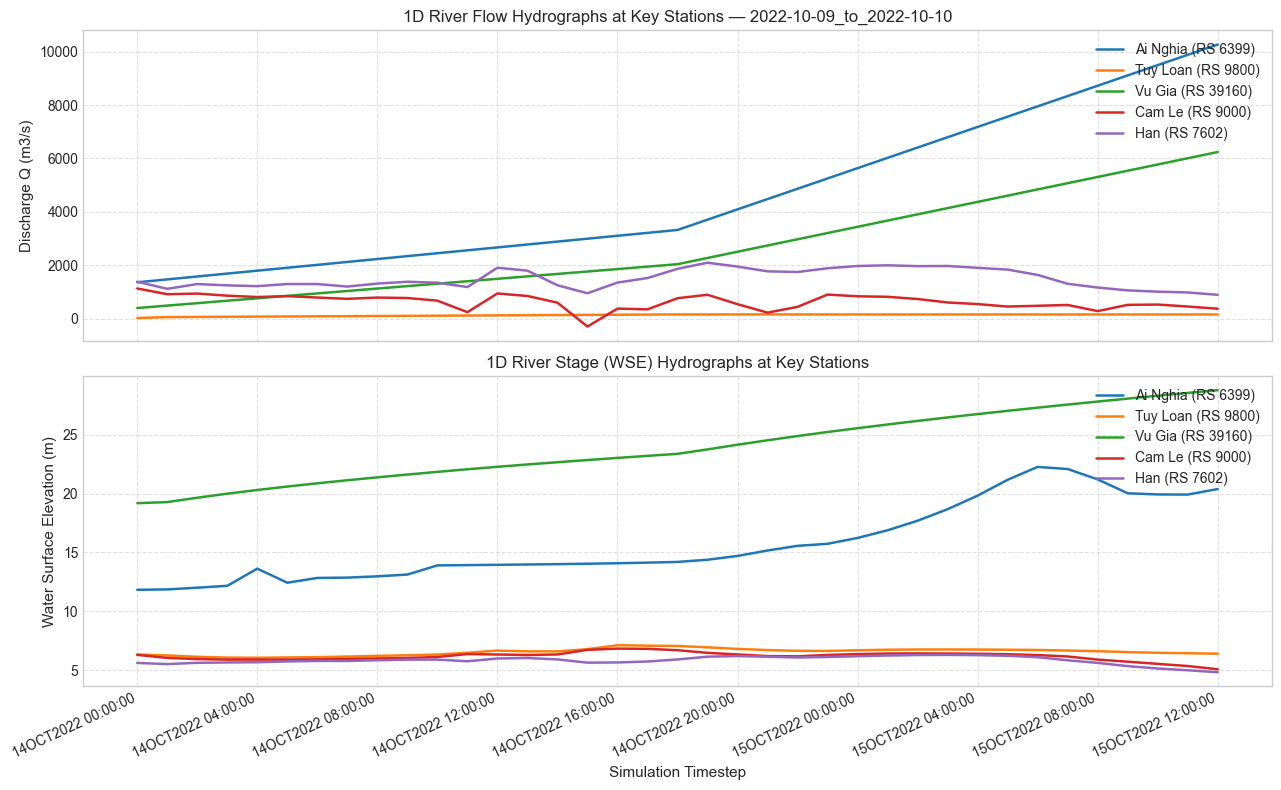

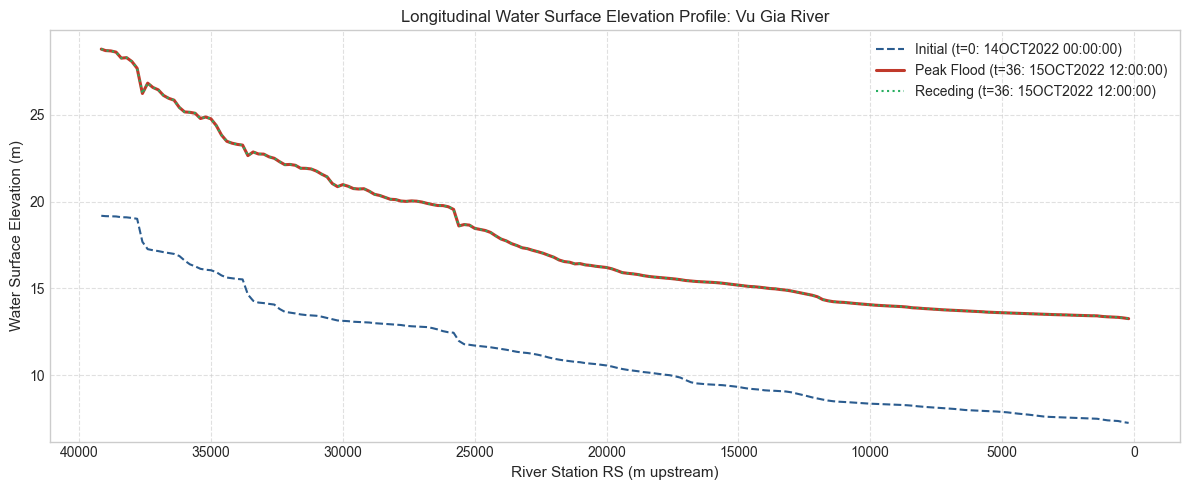

In [6]:
# Cell 6: 1D Visualizations (Hydrographs & Longitudinal River Profiles)
key_stations = [
    ('Ai Nghia', '6399'),
    ('Tuy Loan', '9800'),
    ('Vu Gia', '39160'),
    ('Cam Le', '9000'),
    ('Han', '7602'),
]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
time_idx = np.arange(len(time_stamps))

for riv, rs_val in key_stations:
    match = xs_df[(xs_df['River'].str.lower() == riv.lower()) & (xs_df['RS_str'] == rs_val)]
    if not match.empty:
        idx = match.iloc[0]['xs_index']
        label = f'{riv} (RS {rs_val})'
        ax1.plot(time_idx, flow_matrix[:, idx], label=label, linewidth=1.8)
        ax2.plot(time_idx, wse_matrix[:, idx], label=label, linewidth=1.8)

ax1.set_ylabel('Discharge Q (m3/s)')
ax1.set_title(f'1D River Flow Hydrographs at Key Stations — {TARGET_RUN_ID}')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend(loc='upper right')

ax2.set_ylabel('Water Surface Elevation (m)')
ax2.set_xlabel('Simulation Timestep')
ax2.set_title('1D River Stage (WSE) Hydrographs at Key Stations')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend(loc='upper right')

if len(time_stamps) > 1:
    step_stride = max(1, len(time_stamps) // 8)
    sample_ticks = np.arange(0, len(time_stamps), step_stride)
    ax2.set_xticks(sample_ticks)
    ax2.set_xticklabels([time_stamps[i] for i in sample_ticks], rotation=25, ha='right')

plt.tight_layout()
plt.show()

# Longitudinal Water Surface Elevation Profile along Vu Gia River
SELECT_PROFILE_RIVER = 'Vu Gia'
prof_xs = xs_df[xs_df['River'] == SELECT_PROFILE_RIVER].sort_values(by='RS', ascending=False)

if not prof_xs.empty:
    indices = prof_xs['xs_index'].values
    rs_vals = prof_xs['RS'].values
    
    t_init = 0
    t_end = len(time_stamps) - 1
    reach_flows = flow_matrix[:, indices]
    t_peak = int(np.argmax(np.nanmax(reach_flows, axis=1)))

    plt.figure(figsize=(12, 5))
    plt.plot(rs_vals, wse_matrix[t_init, indices], label=f'Initial (t={t_init}: {time_stamps[t_init]})', color='#2b5c8f', linestyle='--')
    plt.plot(rs_vals, wse_matrix[t_peak, indices], label=f'Peak Flood (t={t_peak}: {time_stamps[t_peak]})', color='#c0392b', linewidth=2.2)
    plt.plot(rs_vals, wse_matrix[t_end, indices], label=f'Receding (t={t_end}: {time_stamps[t_end]})', color='#27ae60', linestyle=':')

    plt.gca().invert_xaxis()  # Downstream is to the right (decreasing RS)
    plt.title(f'Longitudinal Water Surface Elevation Profile: {SELECT_PROFILE_RIVER} River')
    plt.xlabel('River Station RS (m upstream)')
    plt.ylabel('Water Surface Elevation (m)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


=== 2D FLOW AREAS INUNDATION SUMMARY ===


,2D Flow Area,Total Cells,Total Mesh Area (km2),Max Flooded Area (km2),Flooded Extent (%),Max Water Depth (m),Mean Flooded Depth (m)
0,Perimeter 1,109441,43.35,35.75,82.5%,4.87,0.47
1,Perimeter 2,31671,12.39,10.21,82.4%,5.11,0.45


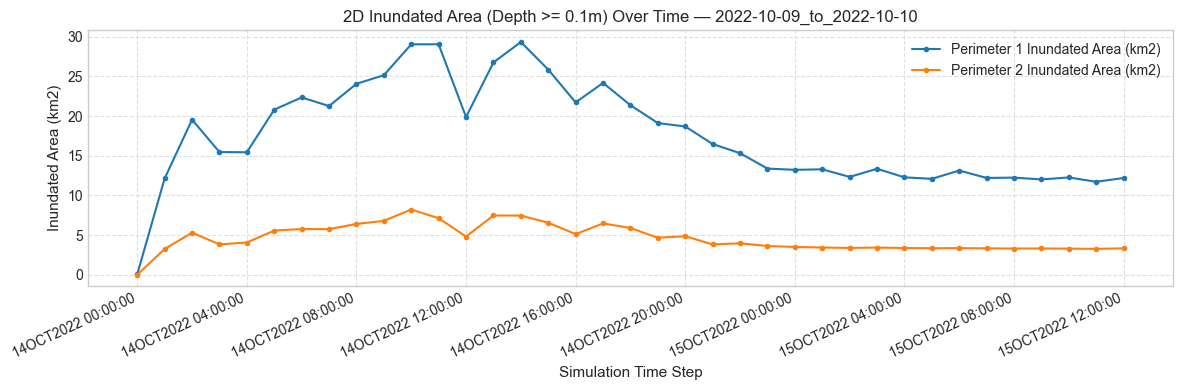

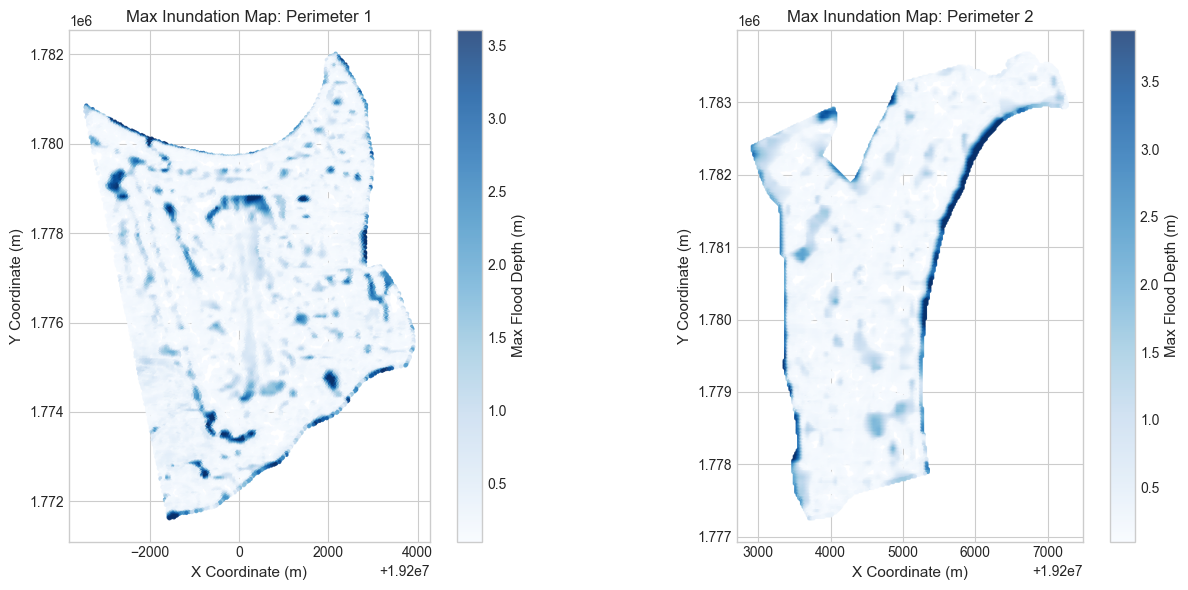

In [7]:
# Cell 7: 2D Flow Areas Inundation Assessment (Perimeter 1 & Perimeter 2)
with h5py.File(hdf_file, 'r') as hdf:
    geom_2d = hdf.get('Geometry/2D Flow Areas', {})
    ts_2d = hdf.get('Results/Unsteady/Output/Output Blocks/Base Output/Unsteady Time Series/2D Flow Areas', {})
    
    area_names = [k for k in ['Perimeter 1', 'Perimeter 2'] if k in ts_2d and k in geom_2d]
    
    summary_2d = []
    plot_data_2d = {}

    for name in area_names:
        g = geom_2d[name]
        t = ts_2d[name]

        coords = g['Cells Center Coordinate'][:]       # (N_cells, 2)
        min_elev = g['Cells Minimum Elevation'][:]     # (N_cells,)
        cell_areas = g['Cells Surface Area'][:]        # (N_cells,)
        wse_2d = t['Water Surface'][:]                 # (timesteps, N_cells)

        # Maximum WSE and Depth per cell across all timesteps
        max_wse_per_cell = np.nanmax(wse_2d, axis=0)
        max_depth_per_cell = np.maximum(0.0, max_wse_per_cell - min_elev)

        # Cells with depth >= 10 cm (0.10 m)
        is_flooded = max_depth_per_cell >= 0.10
        total_mesh_area_km2 = np.sum(cell_areas) / 1e6
        peak_flooded_area_km2 = np.sum(cell_areas[is_flooded]) / 1e6
        max_depth_val = float(np.nanmax(max_depth_per_cell))
        mean_flooded_depth = float(np.nanmean(max_depth_per_cell[is_flooded])) if np.any(is_flooded) else 0.0

        # Inundation progression over time
        inundated_area_series_km2 = []
        for step in range(wse_2d.shape[0]):
            depth_step = np.maximum(0.0, wse_2d[step, :] - min_elev)
            wet_step = depth_step >= 0.10
            inundated_area_series_km2.append(np.sum(cell_areas[wet_step]) / 1e6)

        summary_2d.append({
            '2D Flow Area': name,
            'Total Cells': len(cell_areas),
            'Total Mesh Area (km2)': f'{total_mesh_area_km2:.2f}',
            'Max Flooded Area (km2)': f'{peak_flooded_area_km2:.2f}',
            'Flooded Extent (%)': f'{peak_flooded_area_km2 / total_mesh_area_km2 * 100:.1f}%',
            'Max Water Depth (m)': f'{max_depth_val:.2f}',
            'Mean Flooded Depth (m)': f'{mean_flooded_depth:.2f}',
        })

        plot_data_2d[name] = {
            'coords': coords,
            'max_depth': max_depth_per_cell,
            'is_flooded': is_flooded,
            'area_series': inundated_area_series_km2,
        }

print('=== 2D FLOW AREAS INUNDATION SUMMARY ===')
display(pd.DataFrame(summary_2d))

# Plot Inundated Area over Time
fig, ax = plt.subplots(figsize=(12, 4))
for name in area_names:
    ax.plot(time_idx, plot_data_2d[name]['area_series'], marker='o', markersize=3, label=f"{name} Inundated Area (km2)")
ax.set_title(f'2D Inundated Area (Depth >= 0.1m) Over Time — {TARGET_RUN_ID}')
ax.set_ylabel('Inundated Area (km2)')
ax.set_xlabel('Simulation Time Step')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
if len(time_stamps) > 1:
    step_stride = max(1, len(time_stamps) // 8)
    sample_ticks = np.arange(0, len(time_stamps), step_stride)
    ax.set_xticks(sample_ticks)
    ax.set_xticklabels([time_stamps[i] for i in sample_ticks], rotation=25, ha='right')
plt.tight_layout()
plt.show()

# Plot Spatial 2D Maximum Flood Inundation Map
fig, axes = plt.subplots(1, len(area_names), figsize=(7 * len(area_names), 6), squeeze=False)
for idx, name in enumerate(area_names):
    ax = axes[0, idx]
    data = plot_data_2d[name]
    wet = data['is_flooded']
    if np.any(wet):
        stride = max(1, np.sum(wet) // 25000)  # Subsample for rendering performance
        wet_indices = np.where(wet)[0][::stride]
        sc = ax.scatter(
            data['coords'][wet_indices, 0],
            data['coords'][wet_indices, 1],
            c=data['max_depth'][wet_indices],
            cmap='Blues',
            s=4,
            alpha=0.8,
            vmin=0.1,
            vmax=min(8.0, float(np.percentile(data['max_depth'][wet], 99.5)))
        )
        cbar = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Max Flood Depth (m)')
    ax.set_title(f'Max Inundation Map: {name}')
    ax.set_xlabel('X Coordinate (m)')
    ax.set_ylabel('Y Coordinate (m)')
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()


In [8]:
# Cell 8: Consolidated Assessment Summary Report & Export
peak_ai_nghia = xs_df[xs_df['River'] == 'Ai Nghia']['Peak_Flow_m3s'].max() if not xs_df[xs_df['River'] == 'Ai Nghia'].empty else np.nan
peak_tuy_loan = xs_df[xs_df['River'] == 'Tuy Loan']['Peak_Flow_m3s'].max() if not xs_df[xs_df['River'] == 'Tuy Loan'].empty else np.nan
peak_vu_gia = xs_df[xs_df['River'] == 'Vu Gia']['Peak_Flow_m3s'].max() if not xs_df[xs_df['River'] == 'Vu Gia'].empty else np.nan
peak_han_stage = xs_df[xs_df['River'] == 'Han']['Peak_WSE_m'].max() if not xs_df[xs_df['River'] == 'Han'].empty else np.nan

total_2d_flooded_km2 = sum(float(s['Max Flooded Area (km2)']) for s in summary_2d) if summary_2d else 0.0
overall_max_depth = max(float(s['Max Water Depth (m)']) for s in summary_2d) if summary_2d else 0.0

run_report = {
    'Run ID': TARGET_RUN_ID,
    'Status': 'PASS' if not missing_critical else 'FAIL',
    'Start Time': start_time_str,
    'End Time': end_time_str,
    'Total Timesteps': total_steps,
    'Ai Nghia Peak Q (m3/s)': round(peak_ai_nghia, 2),
    'Tuy Loan Peak Q (m3/s)': round(peak_tuy_loan, 2),
    'Vu Gia Peak Q (m3/s)': round(peak_vu_gia, 2),
    'Han River Peak WSE (m)': round(peak_han_stage, 2),
    'Total 2D Flooded Area (km2)': round(total_2d_flooded_km2, 2),
    'Peak 2D Flood Depth (m)': round(overall_max_depth, 2),
    'Assessed Date': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

report_df = pd.DataFrame([run_report])
print('=== CONSOLIDATED RUN ASSESSMENT REPORT ===')
display(report_df.T.rename(columns={0: 'Value'}))

# Save report as CSV inside the target run directory
out_csv = TARGET_DIR / 'run_assessment_summary.csv'
report_df.to_csv(out_csv, index=False)
print(f'\n[SAVED] Successfully saved summary report to: {out_csv}')


=== CONSOLIDATED RUN ASSESSMENT REPORT ===


,Value
Run ID,2022-10-09_to_2022-10-10
Status,PASS
Start Time,14OCT2022 00:00:00
End Time,15OCT2022 12:00:00
Total Timesteps,37
Ai Nghia Peak Q (m3/s),12016.389648
Tuy Loan Peak Q (m3/s),420.350006
Vu Gia Peak Q (m3/s),6242.290039
Han River Peak WSE (m),6.29
Total 2D Flooded Area (km2),45.96



[SAVED] Successfully saved summary report to: D:\flood prediction\Data Collections\automated_runs\2022-10-09_to_2022-10-10\run_assessment_summary.csv
